In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


Text(0, 0.5, 'Y dataset')

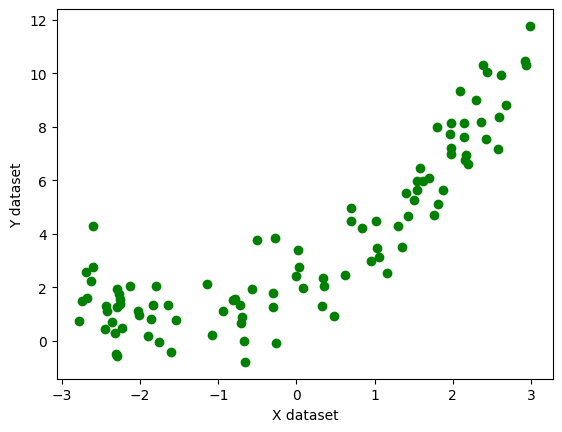

In [7]:
x = 6 * np.random.rand(100,1) - 3
#print(x)
y = 0.5 * x**2 + 1.5*x + 2 + np.random.randn(100,1) # y= 0.5x^2 + 1.5x + 2 + outliers

plt.scatter(x,y,color = 'g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [9]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [ ]:
#Simple Linear

from sklearn.linear_model import LinearRegression

regression1 = LinearRegression()
regression1.fit(X_train,y_train)

from sklearn.metrics import r2_score

score = r2_score(y_test, regression1.predict(X_test)) #y_pred = regression.predict(X_test)
score


0.7133234358618278

[[1.44218856]]


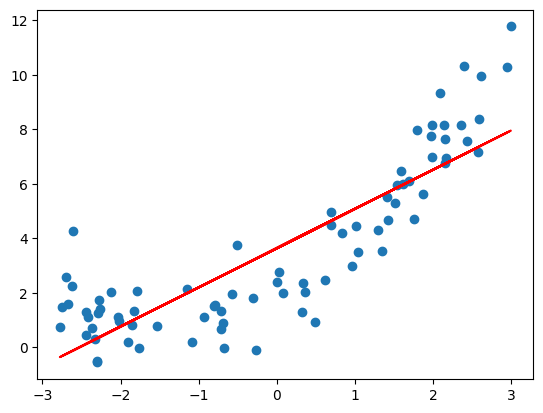

In [ ]:
plt.plot(X_train,regression1.predict(X_train), color = 'r')
plt.scatter(X_train,y_train)



In [16]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2,include_bias = True)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
regression1 = LinearRegression()
regression1.fit(X_train_poly,y_train)

from sklearn.metrics import r2_score

score = r2_score(y_test, regression1.predict(X_test_poly)) #y_pred = regression.predict(X_test)

[[ 5.13031661]
 [ 0.47712554]
 [-0.4087792 ]
 [ 2.54769177]
 [10.04126642]
 [-0.79344472]
 [ 3.83071058]
 [10.46016502]
 [ 1.93064648]
 [ 9.00113313]
 [ 3.38802003]
 [ 7.19489054]
 [ 1.24651072]
 [ 2.75962597]
 [ 6.60312278]
 [ 1.34527755]
 [ 3.11745847]
 [ 8.8131178 ]
 [ 5.63778746]
 [ 1.55560735]]


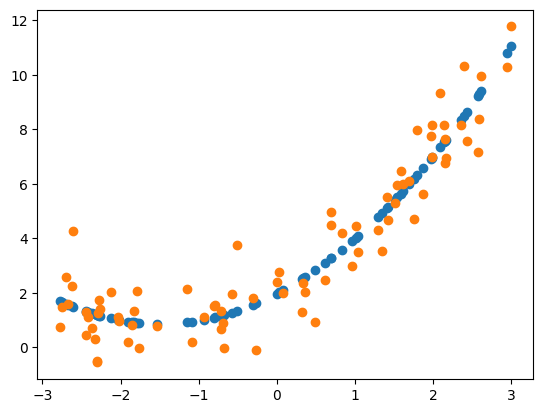

In [21]:
plt.scatter(X_train, regression1.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [24]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

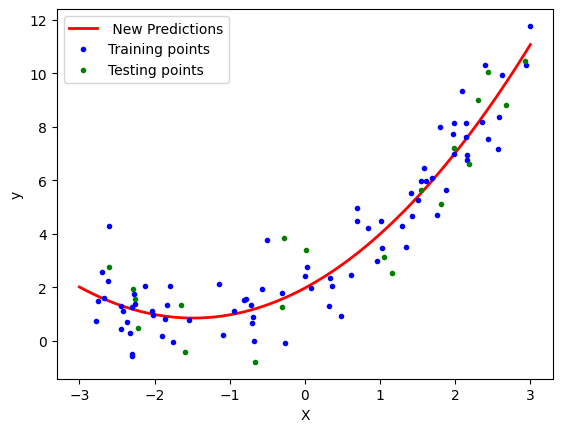

In [25]:
y_new = regression1.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

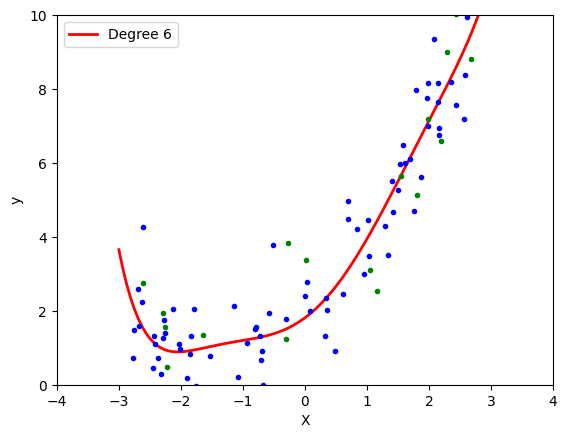

In [27]:
from sklearn.pipeline import Pipeline

def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

poly_regression(6)